# Лабораторная работа №2 — Свёрточные нейронные сети

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint

## 1. Загрузка и визуализация данных

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('Train:', x_train.shape, y_train.shape)
print('Test: ', x_test.shape,  y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 53s 0us/step


c:\Users\globa\OneDrive\Документы\study\deep_learning\lab2\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (50000, 32, 32, 3) (50000, 1)
Test:  (10000, 32, 32, 3) (10000, 1)


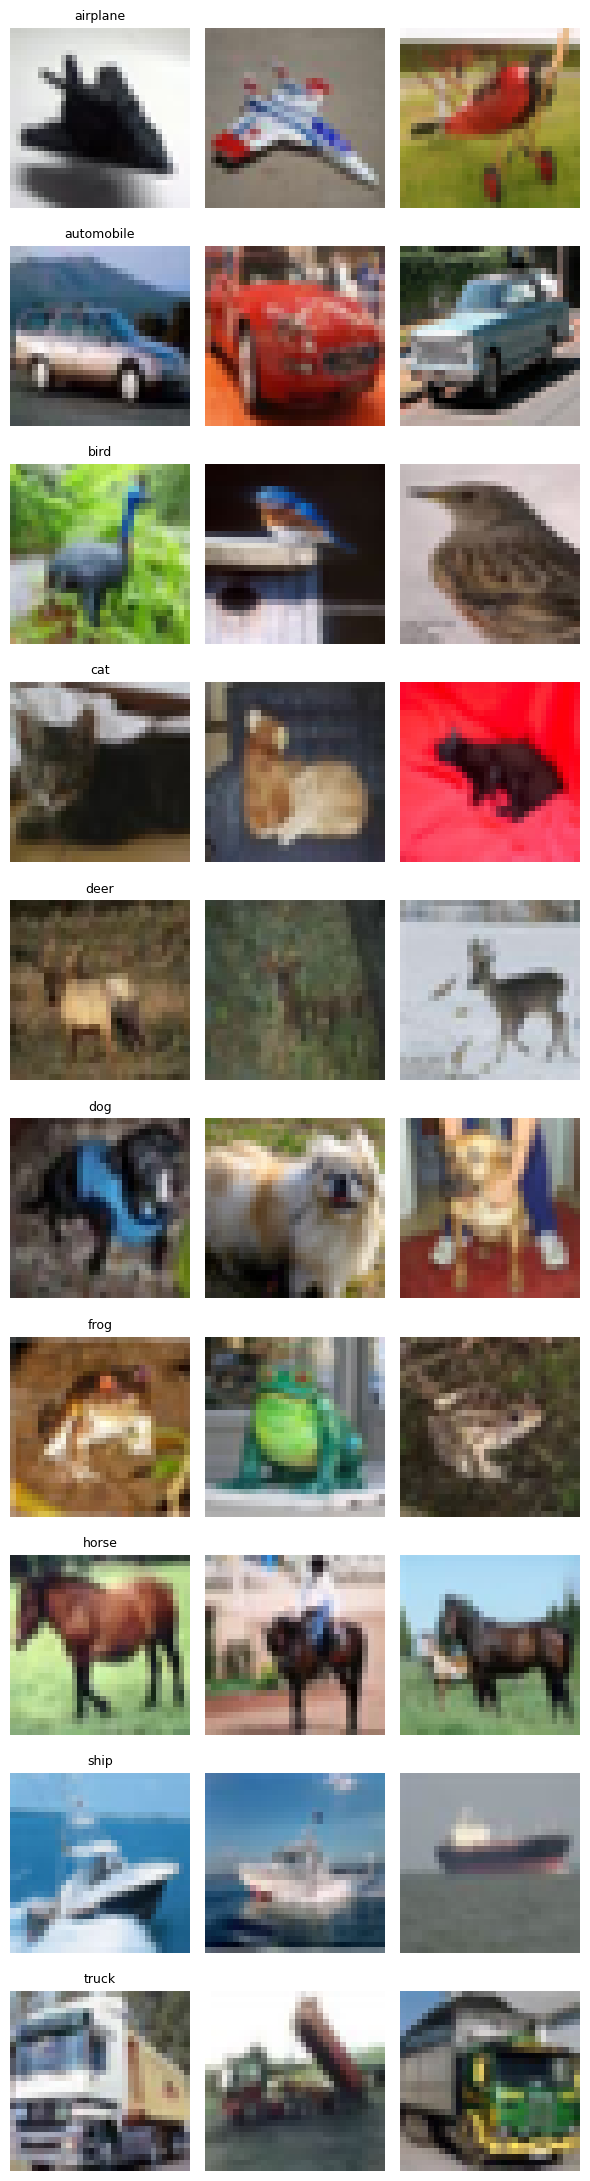

In [3]:
# По 3 изображения каждого класса
fig, axes = plt.subplots(10, 3, figsize=(6, 22))
for cls in range(10):
    idxs = np.where(y_train.flatten() == cls)[0][:3]
    for col, idx in enumerate(idxs):
        axes[cls, col].imshow(x_train[idx])
        axes[cls, col].axis('off')
        if col == 0:
            axes[cls, col].set_title(CLASS_NAMES[cls], fontsize=9)
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=100)
plt.show()

In [4]:
# Нормализация
x_train_n = x_train.astype('float32') / 255.0
x_test_n  = x_test.astype('float32')  / 255.0

# One-hot
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test,  10)

## 2. Модель на 10 классах

### Формула числа параметров сверточного слоя:
$$N_{params} = (M_1 \times M_2 \times K_{in} + 1) \times K_{out}$$
где $M_1, M_2$ — размер ядра, $K_{in}$ — глубина входа, $K_{out}$ — число фильтров, $+1$ — bias.

Например, первый слой Conv2D(32, 3x3) на RGB входе:
$(3 \times 3 \times 3 + 1) \times 32 = 896$ параметров.

In [5]:
def build_model(num_classes=10):
    model = keras.Sequential([
        # Входной слой
        layers.Input(shape=(32, 32, 3)),

        # Блок 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Блок 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Блок 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Классификатор
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_model(10)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    'best_weights_10cls.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

history = model.fit(
    x_train_n, y_train_oh,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint]
)

Epoch 1/30
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3675 - loss: 1.7261
Epoch 1: val_accuracy improved from None to 0.61080, saving model to best_weights_10cls.weights.h5

Epoch 1: finished saving model to best_weights_10cls.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4724 - loss: 1.4603 - val_accuracy: 0.6108 - val_loss: 1.1133
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6131 - loss: 1.0899
Epoch 2: val_accuracy improved from 0.61080 to 0.67160, saving model to best_weights_10cls.weights.h5

Epoch 2: finished saving model to best_weights_10cls.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6307 - loss: 1.0435 - val_accuracy: 0.6716 - val_loss: 0.9355
Epoch 3/30
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6838 - loss: 0.8985
Epoch 3: val_accuracy improved from 0.67160 to 0.72540, saving model to best_weights_10cls.weights.h5

Epoch 3: finished saving model to best_weights_10cls.weights.h5
704

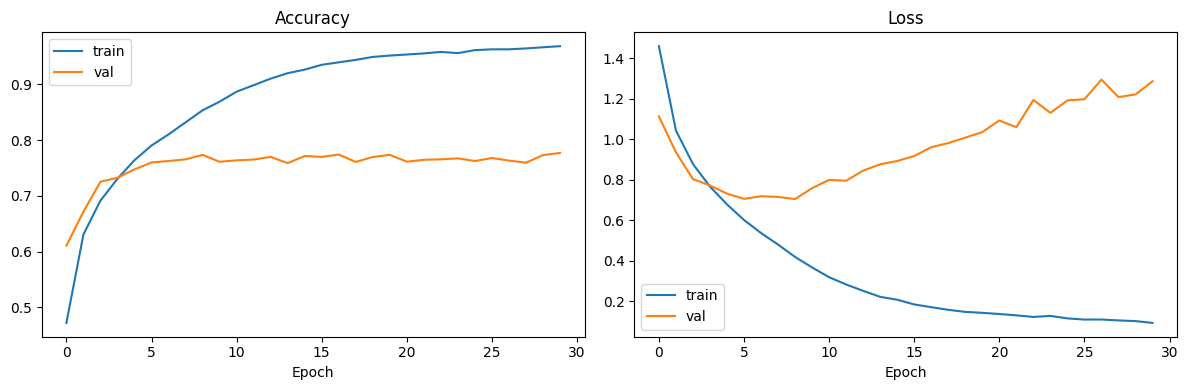

In [7]:
# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves_10cls.png', dpi=100)
plt.show()

In [8]:
# Загружаем лучшие веса и сохраняем модель
model.load_weights('best_weights_10cls.weights.h5')
model.save('model_10cls.keras')
print('Модель сохранена')

Модель сохранена


In [9]:
# Классификация тестовой выборки
y_pred_prob = model.predict(x_test_n)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

# Точность по каждому классу
print('Точность по классам:')
per_class_acc_10cls = {}
for cls in range(10):
    mask = y_true == cls
    acc = np.mean(y_pred[mask] == y_true[mask])
    per_class_acc_10cls[cls] = acc
    print(f'  {CLASS_NAMES[cls]:12s}: {acc*100:.1f}%')

total_acc = np.mean(y_pred == y_true)
print(f'\nОбщая точность: {total_acc*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Точность по классам:
  airplane    : 78.6%
  automobile  : 88.1%
  bird        : 67.7%
  cat         : 54.1%
  deer        : 72.4%
  dog         : 64.9%
  frog        : 81.9%
  horse       : 83.3%
  ship        : 83.0%
  truck       : 82.7%

Общая точность: 75.67%


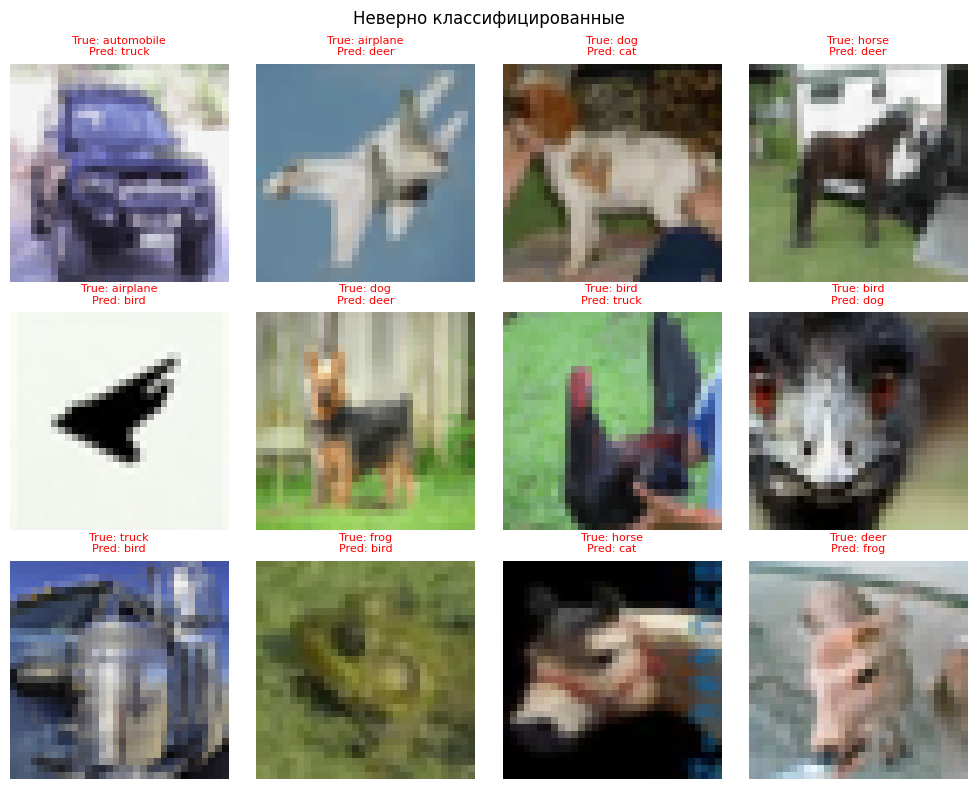

In [10]:
# Несколько неверно классифицированных изображений
wrong_idxs = np.where(y_pred != y_true)[0][:12]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, idx in zip(axes.flatten(), wrong_idxs):
    ax.imshow(x_test[idx])
    ax.set_title(f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
                 fontsize=8, color='red')
    ax.axis('off')
plt.suptitle('Неверно классифицированные', fontsize=12)
plt.tight_layout()
plt.savefig('wrong_predictions_10cls.png', dpi=100)
plt.show()

## 3. Transfer Learning
Обучаем на 8 классах (без bird=2, frog=6),
замораживаем сверточные слои, дообучаем на 10 классах.

In [11]:
EXCLUDED = [2, 6]  # bird, frog
KEPT     = [c for c in range(10) if c not in EXCLUDED]  # [0,1,3,4,5,7,8,9]

# Маска — только примеры 8 классов
mask_train = np.isin(y_train.flatten(), KEPT)
mask_test  = np.isin(y_test.flatten(),  KEPT)

x_train_8 = x_train_n[mask_train]
y_train_8_raw = y_train.flatten()[mask_train]

x_test_8 = x_test_n[mask_test]
y_test_8_raw = y_test.flatten()[mask_test]

# Перемаппируем метки 0..9 -> 0..7
label_map = {old: new for new, old in enumerate(KEPT)}
y_train_8 = np.array([label_map[l] for l in y_train_8_raw])
y_test_8  = np.array([label_map[l] for l in y_test_8_raw])

y_train_8_oh = keras.utils.to_categorical(y_train_8, 8)
y_test_8_oh  = keras.utils.to_categorical(y_test_8,  8)

print('Train 8 cls:', x_train_8.shape)
print('Test  8 cls:', x_test_8.shape)

Train 8 cls: (40000, 32, 32, 3)
Test  8 cls: (8000, 32, 32, 3)


In [12]:
# Модель на 8 классов
model_8 = build_model(8)

model_8.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_8 = ModelCheckpoint(
    'best_weights_8cls.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

history_8 = model_8.fit(
    x_train_8, y_train_8_oh,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint_8]
)

model_8.load_weights('best_weights_8cls.weights.h5')

Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4228 - loss: 1.5070
Epoch 1: val_accuracy improved from None to 0.62075, saving model to best_weights_8cls.weights.h5

Epoch 1: finished saving model to best_weights_8cls.weights.h5
563/563 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5179 - loss: 1.2814 - val_accuracy: 0.6208 - val_loss: 0.9948
Epoch 2/30
561/563 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6526 - loss: 0.9411
Epoch 2: val_accuracy improved from 0.62075 to 0.73425, saving model to best_weights_8cls.weights.h5

Epoch 2: finished saving model to best_weights_8cls.weights.h5
563/563 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6697 - loss: 0.8954 - val_accuracy: 0.7343 - val_loss: 0.7546
Epoch 3/30
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7262 - loss: 0.7532
Epoch 3: val_accuracy improved from 0.73425 to 0.75425, saving model to best_weights_8cls.weights.h5

Epoch 3: finished saving model to best_weights_8cls.weights.h5
563/563 ━

In [13]:
# Удаляем последние 2 полносвязных слоя (Dense 256 + Dense 8)
print('Слои до удаления:')
for i, layer in enumerate(model_8.layers):
    print(f'  {i}: {layer.name} ({layer.__class__.__name__})')

model_8.pop()  # Dense(8)  — выходной
model_8.pop()  # Dense(256) — скрытый

print('\nСлои после удаления:')
for i, layer in enumerate(model_8.layers):
    print(f'  {i}: {layer.name} ({layer.__class__.__name__})')

Слои до удаления:
  0: conv2d_3 (Conv2D)
  1: max_pooling2d_3 (MaxPooling2D)
  2: conv2d_4 (Conv2D)
  3: max_pooling2d_4 (MaxPooling2D)
  4: conv2d_5 (Conv2D)
  5: max_pooling2d_5 (MaxPooling2D)
  6: flatten_1 (Flatten)
  7: dropout_1 (Dropout)
  8: dense_2 (Dense)
  9: dense_3 (Dense)

Слои после удаления:
  0: conv2d_3 (Conv2D)
  1: max_pooling2d_3 (MaxPooling2D)
  2: conv2d_4 (Conv2D)
  3: max_pooling2d_4 (MaxPooling2D)
  4: conv2d_5 (Conv2D)
  5: max_pooling2d_5 (MaxPooling2D)
  6: flatten_1 (Flatten)
  7: dropout_1 (Dropout)


In [14]:
# Замораживаем все оставшиеся слои
model_8.trainable = False

# Строим новую модель поверх замороженной базы
inp = keras.Input(shape=(32, 32, 3))
x   = model_8(inp, training=False)
x   = layers.Dense(256, activation='relu')(x)
out = layers.Dense(10,  activation='softmax')(x)

model_tl = keras.Model(inputs=inp, outputs=out)
model_tl.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 2048)           │        93,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 93,248 (364.25 KB)

In [15]:
model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_tl = ModelCheckpoint(
    'best_weights_tl.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

history_tl = model_tl.fit(
    x_train_n, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[checkpoint_tl]
)

model_tl.load_weights('best_weights_tl.weights.h5')

Epoch 1/20
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6731 - loss: 0.9584
Epoch 1: val_accuracy improved from None to 0.74680, saving model to best_weights_tl.weights.h5

Epoch 1: finished saving model to best_weights_tl.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7302 - loss: 0.7813 - val_accuracy: 0.7468 - val_loss: 0.7440
Epoch 2/20
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8032 - loss: 0.5632
Epoch 2: val_accuracy improved from 0.74680 to 0.75840, saving model to best_weights_tl.weights.h5

Epoch 2: finished saving model to best_weights_tl.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8020 - loss: 0.5674 - val_accuracy: 0.7584 - val_loss: 0.7209
Epoch 3/20
701/704 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8351 - loss: 0.4648
Epoch 3: val_accuracy improved from 0.75840 to 0.77100, saving model to best_weights_tl.weights.h5

Epoch 3: finished saving model to best_weights_tl.weights.h5
704/704 ━━━━━━━━━━━━━

In [16]:
# Сравнение точности на выброшенных классах
y_pred_tl = np.argmax(model_tl.predict(x_test_n), axis=1)

print('Сравнение точности на выброшенных классах (bird=2, frog=6):\n')
print(f'{"Класс":12s} | {"Модель п.2":12s} | {"Transfer Learning":18s}')
print('-' * 48)
for cls in EXCLUDED:
    mask = y_true == cls
    acc_base = per_class_acc_10cls[cls]
    acc_tl   = np.mean(y_pred_tl[mask] == y_true[mask])
    print(f'{CLASS_NAMES[cls]:12s} | {acc_base*100:10.1f}% | {acc_tl*100:16.1f}%')

print('\nОбщая точность:')
print(f'  Модель п.2:        {np.mean(y_pred    == y_true)*100:.2f}%')
print(f'  Transfer Learning: {np.mean(y_pred_tl == y_true)*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Сравнение точности на выброшенных классах (bird=2, frog=6):

Класс        | Модель п.2   | Transfer Learning 
------------------------------------------------
bird         |       67.7% |             62.4%
frog         |       81.9% |             84.6%

Общая точность:
  Модель п.2:        75.67%
  Transfer Learning: 76.28%


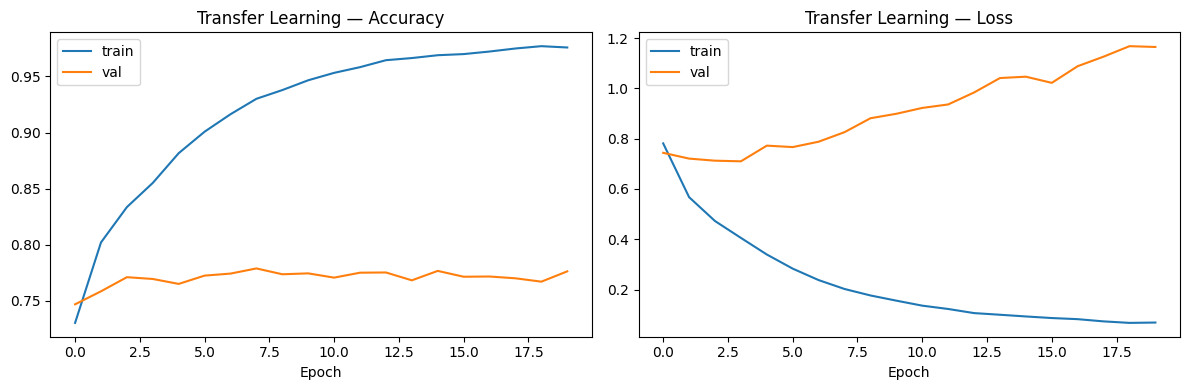

In [17]:
# Графики transfer learning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_tl.history['accuracy'],     label='train')
ax1.plot(history_tl.history['val_accuracy'], label='val')
ax1.set_title('Transfer Learning — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_tl.history['loss'],     label='train')
ax2.plot(history_tl.history['val_loss'], label='val')
ax2.set_title('Transfer Learning — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves_tl.png', dpi=100)
plt.show()